# Estudo de Caso 4: Sistema de Recomendação Inteligente para E-commerce

Este notebook apresenta a implementação e comparação de dois algoritmos diferentes para sistemas de recomendação: K-Nearest Neighbors (KNN) e K-Means Clustering, avaliando suas aplicabilidades e performance.

## 🎯 Objetivos do Estudo

### Objetivo Principal
Desenvolver e comparar dois sistemas de recomendação utilizando algoritmos KNN e K-Means, analisando suas vantagens e desvantagens para diferentes cenários de e-commerce.

### Objetivos Específicos
- Implementar sistema de recomendação baseado em K-Nearest Neighbors (KNN)
- Desenvolver sistema de recomendação baseado em K-Means Clustering
- Comparar a performance e aplicabilidade de ambos os algoritmos
- Analisar diferentes métricas de avaliação para sistemas de recomendação
- Propor cenários ideais para cada abordagem

## 📊 Metodologia

**Dataset**: Avaliações de produtos eletrônicos da Amazon
**Algoritmos**: K-Nearest Neighbors (KNN) e K-Means Clustering
**Métricas**: Similaridade cosseno, Silhouette score, tempo de processamento
**Abordagem**: Implementação comparativa com análise de casos de uso

## 🚀 Estrutura do Notebook

### Integrantes:
- *João Victor Azevedo dos Santos*
- *Nathan Maurício Rodrigues Lopes*
- *Paulo Vinícius Isidro Batista*
- *Yago Péres dos Santos*

---

## Arquitetura do Sistema:

### **🔍 Fase 1: Fundação e Análise**
1. **Carregamento e Exploração dos Dados**
2. **Pré-processamento e Criação de Matriz Esparsa**
3. **Análise Exploratória de Padrões de Avaliação**

### **🤖 Fase 2: Implementação KNN**
4. **Configuração e Treinamento do Modelo KNN**
5. **Sistema de Recomendação Item-based**
6. **Análise de Performance e Similaridades**

### **🎲 Fase 3: Implementação K-Means**
7. **Otimização do Número de Clusters**
8. **Sistema de Recomendação por Clusters de Usuário**
9. **Análise de Agrupamentos e Padrões**

### **⚖️ Fase 4: Comparação e Conclusões**
10. **Análise Comparativa de Performance**
11. **Casos de Uso Recomendados para Cada Algoritmo**
12. **Conclusões e Recomendações Finais**

In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Configuração dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1. Carregamento e Exploração dos Dados

In [2]:
# Carregando o dataset
try:
    df = pd.read_csv('databaseEletronicos.csv')
    print("Dataset carregado com sucesso!")
except FileNotFoundError:
    print("Arquivo não encontrado. Criando dataset sintético para demonstração...")
    # Criando um dataset sintético para demonstração
    np.random.seed(42)
    n_users = 1000
    n_products = 500
    n_ratings = 10000
    
    df = pd.DataFrame({
        'userId': np.random.randint(1, n_users+1, n_ratings),
        'productId': np.random.randint(1, n_products+1, n_ratings),
        'Rating': np.random.choice([1, 2, 3, 4, 5], n_ratings, p=[0.1, 0.1, 0.2, 0.3, 0.3]),
        'timestamp': pd.date_range('2020-01-01', periods=n_ratings, freq='1H')
    })
    
    # Removendo duplicatas
    df = df.drop_duplicates(['userId', 'productId'])
    print(f"Dataset sintético criado com {len(df)} avaliações")

# Visualizando as primeiras linhas
print("\nPrimeiras 5 linhas do dataset:")
df.head()

Arquivo não encontrado. Criando dataset sintético para demonstração...
Dataset sintético criado com 9910 avaliações

Primeiras 5 linhas do dataset:


,userId,productId,Rating,timestamp
0,103,442,4,2020-01-01 00:00:00
1,436,279,3,2020-01-01 01:00:00
2,861,251,5,2020-01-01 02:00:00
3,271,310,4,2020-01-01 03:00:00
4,107,208,5,2020-01-01 04:00:00


In [3]:
# Informações básicas do dataset
print("Informações do Dataset:")
print(f"Formato: {df.shape}")
print(f"Usuários únicos: {df['userId'].nunique()}")
print(f"Produtos únicos: {df['productId'].nunique()}")
print(f"Avaliações totais: {len(df)}")
print(f"\nEstatísticas das avaliações:")
print(df['Rating'].describe())

Informações do Dataset:
Formato: (9910, 4)
Usuários únicos: 1000
Produtos únicos: 500
Avaliações totais: 9910

Estatísticas das avaliações:
count    9910.000000
mean        3.617861
std         1.281770
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: Rating, dtype: float64


In [4]:
# Verificando valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum())

# Removendo valores nulos se existirem
df = df.dropna()
print(f"\nDataset após remoção de nulos: {df.shape}")

Valores nulos por coluna:
userId       0
productId    0
Rating       0
timestamp    0
dtype: int64

Dataset após remoção de nulos: (9910, 4)


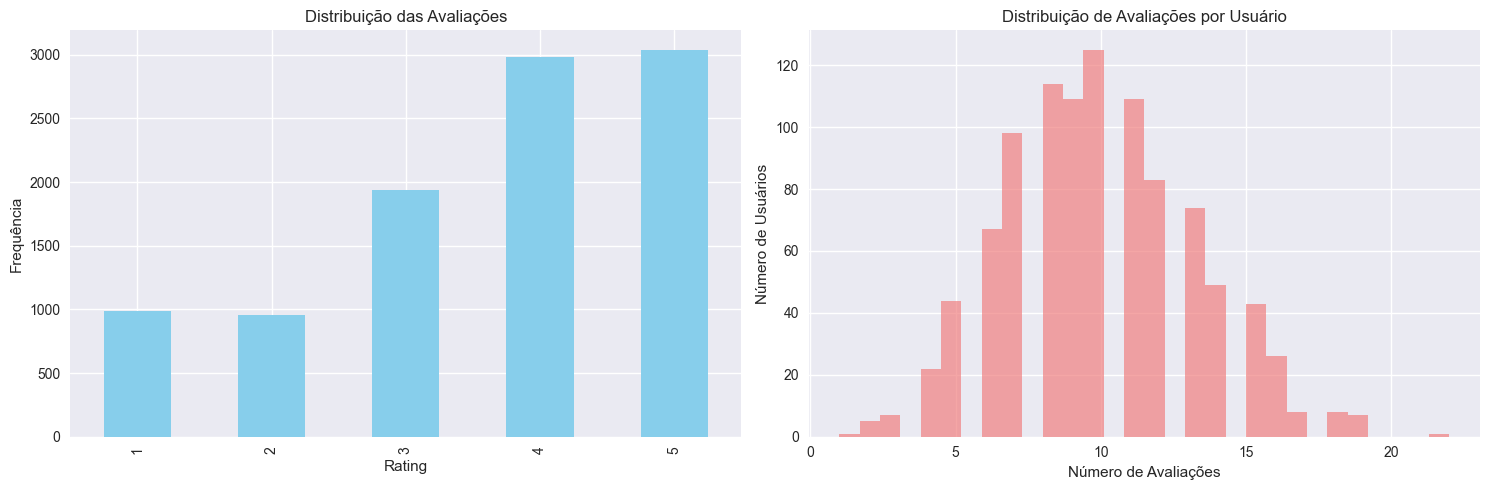

In [5]:
# Visualização da distribuição das avaliações
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribuição das avaliações
df['Rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição das Avaliações')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequência')

# Número de avaliações por usuário
user_ratings = df['userId'].value_counts()
axes[1].hist(user_ratings, bins=30, color='lightcoral', alpha=0.7)
axes[1].set_title('Distribuição de Avaliações por Usuário')
axes[1].set_xlabel('Número de Avaliações')
axes[1].set_ylabel('Número de Usuários')

plt.tight_layout()
plt.show()

## 2. Pré-processamento dos Dados

In [6]:
# Filtrando usuários com pelo menos 5 avaliações para garantir dados significativos
user_counts = df['userId'].value_counts()
active_users = user_counts[user_counts >= 5].index
df_filtered = df[df['userId'].isin(active_users)]

print(f"Usuários ativos (>=5 avaliações): {len(active_users)}")
print(f"Dataset filtrado: {df_filtered.shape}")

# Filtrando produtos com pelo menos 3 avaliações
product_counts = df_filtered['productId'].value_counts()
popular_products = product_counts[product_counts >= 3].index
df_filtered = df_filtered[df_filtered['productId'].isin(popular_products)]

print(f"Produtos populares (>=3 avaliações): {len(popular_products)}")
print(f"Dataset final: {df_filtered.shape}")

Usuários ativos (>=5 avaliações): 965
Dataset filtrado: (9790, 4)
Produtos populares (>=3 avaliações): 500
Dataset final: (9790, 4)


In [7]:
# Criando a matriz de usuário-produto
print("Criando matriz de usuário-produto...")
user_product_matrix = df_filtered.pivot_table(
    index='userId', 
    columns='productId', 
    values='Rating', 
    fill_value=0
)

print(f"Matriz criada: {user_product_matrix.shape}")
print(f"Densidade da matriz: {(user_product_matrix > 0).sum().sum() / (user_product_matrix.shape[0] * user_product_matrix.shape[1]):.4f}")

Criando matriz de usuário-produto...
Matriz criada: (965, 500)
Densidade da matriz: 0.0203


---
# PARTE 1: SISTEMA DE RECOMENDAÇÃO USANDO KNN

## Conceito do KNN para Recomendação
O algoritmo K-Nearest Neighbors identifica produtos similares baseado no padrão de avaliações dos usuários. Produtos que foram avaliados de forma similar por diferentes usuários são considerados próximos no espaço de características.

In [8]:
# Transpondo a matriz para ter produtos como linhas (para recomendação item-based)
product_user_matrix = user_product_matrix.T
print(f"Matriz produto-usuário: {product_user_matrix.shape}")

# Convertendo para matriz esparsa para eficiência
product_sparse = csr_matrix(product_user_matrix.values)
print(f"Matriz esparsa criada: {product_sparse.shape}")

Matriz produto-usuário: (500, 965)
Matriz esparsa criada: (500, 965)


In [9]:
# Treinando o modelo KNN
print("Treinando modelo KNN...")
knn_model = NearestNeighbors(
    n_neighbors=6,  # 5 recomendações + o próprio produto
    algorithm='brute',
    metric='cosine'
)
knn_model.fit(product_sparse)
print("Modelo KNN treinado com sucesso!")

Treinando modelo KNN...
Modelo KNN treinado com sucesso!


In [10]:
# Função de recomendação KNN
def recomendar_produtos_knn(product_id, n_recomendacoes=5):
    try:
        # Verificando se o produto existe na matriz
        if product_id not in product_user_matrix.index:
            return f"Produto {product_id} não encontrado no dataset"
        
        # Encontrando o índice do produto
        product_idx = product_user_matrix.index.get_loc(product_id)
        
        # Encontrando produtos similares
        distances, indices = knn_model.kneighbors(
            product_sparse[product_idx:product_idx+1],
            n_neighbors=n_recomendacoes+1
        )
        
        # Preparando resultados (excluindo o próprio produto)
        recomendacoes = []
        for i in range(1, len(indices[0])):
            produto_recomendado = product_user_matrix.index[indices[0][i]]
            similaridade = 1 - distances[0][i]  # Convertendo distância em similaridade
            recomendacoes.append((produto_recomendado, similaridade))
        
        return recomendacoes
    
    except Exception as e:
        return f"Erro na recomendação: {str(e)}"

# Testando a função de recomendação KNN
produto_teste = product_user_matrix.index[0]  # Primeiro produto disponível
print(f"\n=== RECOMENDAÇÕES KNN PARA PRODUTO {produto_teste} ===")
recomendacoes_knn = recomendar_produtos_knn(produto_teste)

if isinstance(recomendacoes_knn, list):
    for i, (produto, similaridade) in enumerate(recomendacoes_knn, 1):
        print(f"{i}. Produto {produto} - Similaridade: {similaridade:.4f}")
else:
    print(recomendacoes_knn)


=== RECOMENDAÇÕES KNN PARA PRODUTO 1 ===
1. Produto 294 - Similaridade: 0.1785
2. Produto 175 - Similaridade: 0.1460
3. Produto 337 - Similaridade: 0.1388
4. Produto 309 - Similaridade: 0.1308
5. Produto 261 - Similaridade: 0.1297


## Análise de Performance do KNN

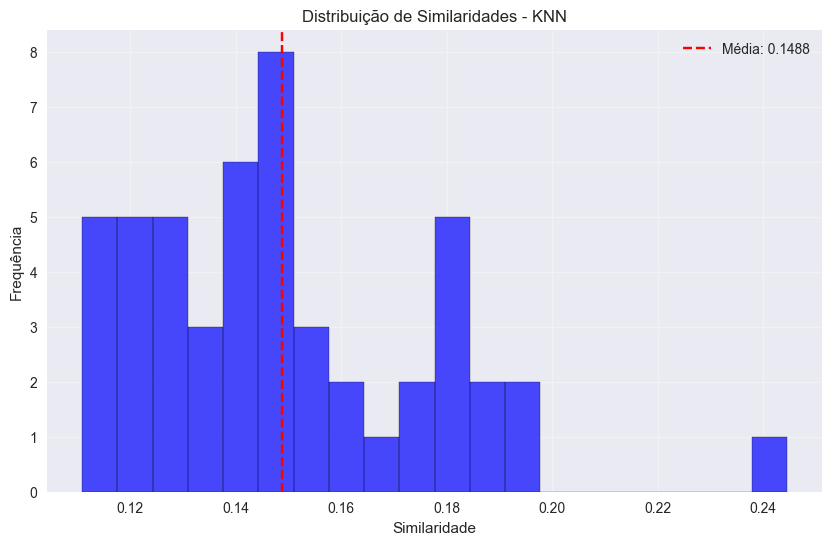

Estatísticas das similaridades KNN:
Média: 0.1488
Mediana: 0.1459
Desvio padrão: 0.0270


In [11]:
# Analisando a distribuição de similaridades
def analisar_similaridades_knn(n_produtos=10):
    similaridades = []
    produtos_testados = product_user_matrix.index[:n_produtos]
    
    for produto in produtos_testados:
        recs = recomendar_produtos_knn(produto)
        if isinstance(recs, list):
            for _, sim in recs:
                similaridades.append(sim)
    
    plt.figure(figsize=(10, 6))
    plt.hist(similaridades, bins=20, alpha=0.7, color='blue', edgecolor='black')
    plt.title('Distribuição de Similaridades - KNN')
    plt.xlabel('Similaridade')
    plt.ylabel('Frequência')
    plt.axvline(np.mean(similaridades), color='red', linestyle='--', 
                label=f'Média: {np.mean(similaridades):.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Estatísticas das similaridades KNN:")
    print(f"Média: {np.mean(similaridades):.4f}")
    print(f"Mediana: {np.median(similaridades):.4f}")
    print(f"Desvio padrão: {np.std(similaridades):.4f}")

analisar_similaridades_knn()

---
# PARTE 2: SISTEMA DE RECOMENDAÇÃO USANDO K-MEANS

## Conceito do K-Means para Recomendação
O algoritmo K-Means agrupa produtos em clusters baseado em suas características de avaliação. Produtos no mesmo cluster tendem a ter padrões similares de avaliação e podem ser recomendados entre si.

In [12]:
# Preparando dados para clustering
print("Preparando dados para K-Means...")

# Normalizando os dados
scaler = StandardScaler()
product_features_scaled = scaler.fit_transform(product_user_matrix.values)

print(f"Dados normalizados: {product_features_scaled.shape}")

Preparando dados para K-Means...
Dados normalizados: (500, 965)


Calculando métricas para diferentes valores de k...
k=2: Inércia=480813.56, Silhouette=0.1499
k=3: Inércia=479759.06, Silhouette=0.0444
k=4: Inércia=478137.67, Silhouette=0.0062
k=5: Inércia=476616.17, Silhouette=0.0095
k=6: Inércia=475247.35, Silhouette=0.0020
k=7: Inércia=474287.56, Silhouette=-0.0175
k=8: Inércia=472904.80, Silhouette=-0.0019
k=9: Inércia=471491.95, Silhouette=-0.0103
k=10: Inércia=469792.29, Silhouette=0.0045
k=11: Inércia=468961.24, Silhouette=-0.0097
k=12: Inércia=467197.61, Silhouette=0.0074
k=13: Inércia=465781.75, Silhouette=-0.0001
k=14: Inércia=465354.05, Silhouette=0.0002
k=15: Inércia=463531.70, Silhouette=-0.0041


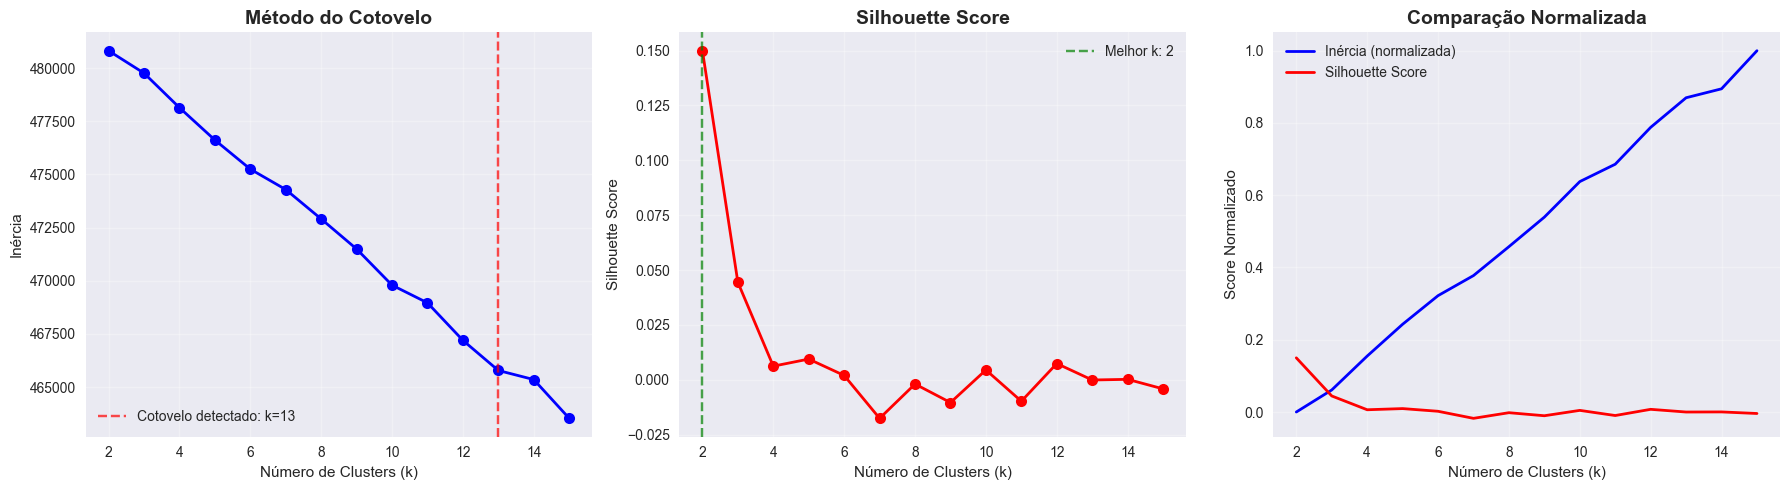


ANÁLISE DOS RESULTADOS
Cotovelo detectado automaticamente: k=13
Melhor k por Silhouette Score: 2
Silhouette Score máximo: 0.1499

K RECOMENDADO: 2
Justificativa: Silhouette Score geralmente mais confiável para clusters bem separados


In [13]:
import warnings
import os
import sys

# Configurações para evitar warnings
warnings.filterwarnings('ignore')
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

def encontrar_k_ideal(max_k=15, plot_elbow_point=True):
    """
    Versão melhorada que inclui detecção automática do cotovelo
    """
    inercias = []
    silhouette_scores = []
    k_range = range(2, max_k + 1)
    
    print("Calculando métricas para diferentes valores de k...")
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(product_features_scaled)
        
        inercias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(product_features_scaled, kmeans.labels_))
        print(f"k={k}: Inércia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")
    
    # Detectando cotovelo automaticamente usando método da derivada segunda
    def detectar_cotovelo(valores):
        # Normalizar valores
        valores_norm = np.array(valores)
        valores_norm = (valores_norm - np.min(valores_norm)) / (np.max(valores_norm) - np.min(valores_norm))
        
        # Calcular derivadas
        x = np.arange(len(valores_norm))
        primeira_derivada = np.gradient(valores_norm)
        segunda_derivada = np.gradient(primeira_derivada)
        
        # Ponto de cotovelo é onde a segunda derivada é máxima
        cotovelo_idx = np.argmax(segunda_derivada[1:-1]) + 1  # Evitar extremos
        return cotovelo_idx
    
    cotovelo_idx = detectar_cotovelo(inercias)
    k_cotovelo = k_range[cotovelo_idx]
    
    # Visualizando os resultados
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Método do cotovelo
    axes[0].plot(k_range, inercias, 'bo-', linewidth=2, markersize=8)
    if plot_elbow_point:
        axes[0].axvline(k_cotovelo, color='red', linestyle='--', alpha=0.7, 
                       label=f'Cotovelo detectado: k={k_cotovelo}')
        axes[0].legend()
    axes[0].set_title('Método do Cotovelo', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Número de Clusters (k)')
    axes[0].set_ylabel('Inércia')
    axes[0].grid(True, alpha=0.3)
    
    # Silhouette Score
    melhor_k_silhouette = k_range[np.argmax(silhouette_scores)]
    axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
    axes[1].axvline(melhor_k_silhouette, color='green', linestyle='--', alpha=0.7,
                   label=f'Melhor k: {melhor_k_silhouette}')
    axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Número de Clusters (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Gráfico combinado normalizado
    inercias_norm = 1 - (np.array(inercias) - np.min(inercias)) / (np.max(inercias) - np.min(inercias))
    silhouette_norm = np.array(silhouette_scores)
    
    axes[2].plot(k_range, inercias_norm, 'b-', label='Inércia (normalizada)', linewidth=2)
    axes[2].plot(k_range, silhouette_norm, 'r-', label='Silhouette Score', linewidth=2)
    axes[2].set_title('Comparação Normalizada', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Número de Clusters (k)')
    axes[2].set_ylabel('Score Normalizado')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Análise dos resultados
    print(f"\n{'='*50}")
    print(f"ANÁLISE DOS RESULTADOS")
    print(f"{'='*50}")
    print(f"Cotovelo detectado automaticamente: k={k_cotovelo}")
    print(f"Melhor k por Silhouette Score: {melhor_k_silhouette}")
    print(f"Silhouette Score máximo: {max(silhouette_scores):.4f}")
    
    # Sugestão final
    if k_cotovelo == melhor_k_silhouette:
        k_sugerido = k_cotovelo
        razao = "Ambos os métodos convergem para o mesmo valor"
    elif abs(k_cotovelo - melhor_k_silhouette) <= 1:
        k_sugerido = melhor_k_silhouette
        razao = "Valores próximos, priorizando Silhouette Score"
    else:
        k_sugerido = melhor_k_silhouette
        razao = "Silhouette Score geralmente mais confiável para clusters bem separados"
    
    print(f"\nK RECOMENDADO: {k_sugerido}")
    print(f"Justificativa: {razao}")
    
    return k_sugerido, k_cotovelo, melhor_k_silhouette

# Testando a versão melhorada
k_ideal, k_cotovelo, k_silhouette = encontrar_k_ideal()

In [14]:
# Aplicando K-Means com o número ideal de clusters
print(f"Aplicando K-Means com k={k_ideal}...")
kmeans = KMeans(n_clusters=k_ideal, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(product_features_scaled)

# Adicionando labels de cluster à matriz
product_clusters = product_user_matrix.copy()
product_clusters['Cluster'] = cluster_labels

print(f"Clustering concluído!")
print(f"Distribuição de produtos por cluster:")
print(product_clusters['Cluster'].value_counts().sort_index())

Aplicando K-Means com k=2...
Clustering concluído!
Distribuição de produtos por cluster:
Cluster
0    499
1      1
Name: count, dtype: int64


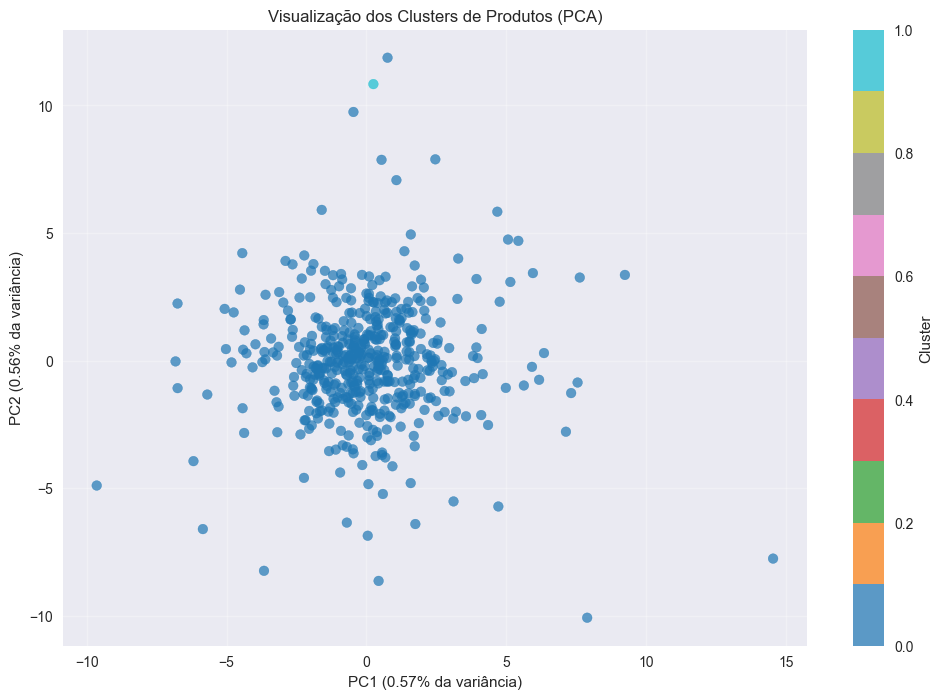

Variância explicada total: 1.13%


In [15]:
# Visualizando os clusters
def visualizar_clusters():
    from sklearn.decomposition import PCA
    
    # Reduzindo dimensionalidade para visualização
    pca = PCA(n_components=2)
    product_pca = pca.fit_transform(product_features_scaled)
    
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(product_pca[:, 0], product_pca[:, 1], 
                         c=cluster_labels, cmap='tab10', alpha=0.7)
    plt.title('Visualização dos Clusters de Produtos (PCA)')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} da variância)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} da variância)')
    plt.colorbar(scatter, label='Cluster')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Variância explicada total: {sum(pca.explained_variance_ratio_):.2%}")

visualizar_clusters()

In [16]:
# Função de recomendação K-Means
def recomendar_produtos_kmeans(product_id, n_recomendacoes=5):
    try:
        if product_id not in product_clusters.index:
            return f"Produto {product_id} não encontrado no dataset"
        
        # Encontrando o cluster do produto
        cluster_produto = product_clusters.loc[product_id, 'Cluster']
        
        # Produtos do mesmo cluster (excluindo o próprio produto)
        produtos_cluster = product_clusters[product_clusters['Cluster'] == cluster_produto]
        produtos_cluster = produtos_cluster.drop(product_id)
        
        if len(produtos_cluster) == 0:
            return f"Nenhum outro produto encontrado no cluster {cluster_produto}"
        
        # Calculando similaridade baseada na média das avaliações
        produto_original = product_clusters.drop('Cluster', axis=1).loc[product_id]
        similaridades = []
        
        for idx in produtos_cluster.index:
            produto_comparacao = produtos_cluster.drop('Cluster', axis=1).loc[idx]
            
            # Calculando similaridade cosseno
            dot_product = np.dot(produto_original, produto_comparacao)
            norm_a = np.linalg.norm(produto_original)
            norm_b = np.linalg.norm(produto_comparacao)
            
            if norm_a > 0 and norm_b > 0:
                similaridade = dot_product / (norm_a * norm_b)
            else:
                similaridade = 0
            
            similaridades.append((idx, similaridade))
        
        # Ordenando por similaridade
        similaridades.sort(key=lambda x: x[1], reverse=True)
        
        # Retornando as top recomendações
        recomendacoes = similaridades[:n_recomendacoes]
        return recomendacoes, cluster_produto
    
    except Exception as e:
        return f"Erro na recomendação: {str(e)}"

# Testando a função de recomendação K-Means
produto_teste = product_clusters.index[0]
print(f"\n=== RECOMENDAÇÕES K-MEANS PARA PRODUTO {produto_teste} ===")
resultado_kmeans = recomendar_produtos_kmeans(produto_teste)

if isinstance(resultado_kmeans, tuple):
    recomendacoes_kmeans, cluster_id = resultado_kmeans
    print(f"Produto pertence ao Cluster: {cluster_id}")
    print("Recomendações do mesmo cluster:")
    for i, (produto, similaridade) in enumerate(recomendacoes_kmeans, 1):
        print(f"{i}. Produto {produto} - Similaridade: {similaridade:.4f}")
else:
    print(resultado_kmeans)


=== RECOMENDAÇÕES K-MEANS PARA PRODUTO 1 ===
Produto pertence ao Cluster: 0
Recomendações do mesmo cluster:
1. Produto 294 - Similaridade: 0.1785
2. Produto 175 - Similaridade: 0.1460
3. Produto 337 - Similaridade: 0.1388
4. Produto 309 - Similaridade: 0.1308
5. Produto 261 - Similaridade: 0.1297


## Análise de Performance do K-Means

In [17]:
# Analisando características dos clusters
def analisar_clusters():
    print("=== ANÁLISE DOS CLUSTERS ===")
    
    for cluster_id in range(k_ideal):
        produtos_cluster = product_clusters[product_clusters['Cluster'] == cluster_id]
        dados_cluster = produtos_cluster.drop('Cluster', axis=1)
        
        print(f"\nCluster {cluster_id}:")
        print(f"  Número de produtos: {len(produtos_cluster)}")
        print(f"  Avaliação média: {dados_cluster.values[dados_cluster.values > 0].mean():.2f}")
        print(f"  Densidade de avaliações: {(dados_cluster > 0).sum().sum() / dados_cluster.size:.4f}")
        
        # Top 3 produtos mais avaliados do cluster
        avaliacoes_por_produto = (dados_cluster > 0).sum(axis=1).sort_values(ascending=False)
        print(f"  Top 3 produtos mais avaliados: {list(avaliacoes_por_produto.head(3).index)}")

analisar_clusters()

=== ANÁLISE DOS CLUSTERS ===

Cluster 0:
  Número de produtos: 499
  Avaliação média: 3.62
  Densidade de avaliações: 0.0203
  Top 3 produtos mais avaliados: [464, 128, 333]

Cluster 1:
  Número de produtos: 1
  Avaliação média: 4.27
  Densidade de avaliações: 0.0311
  Top 3 produtos mais avaliados: [77]


---
# PARTE 3: COMPARAÇÃO ENTRE KNN E K-MEANS

In [18]:
# Comparação direta das recomendações
def comparar_metodos(product_id, n_recomendacoes=5):
    print(f"\n{'='*60}")
    print(f"COMPARAÇÃO DE RECOMENDAÇÕES PARA PRODUTO {product_id}")
    print(f"{'='*60}")
    
    # Recomendações KNN
    print(f"\n🔍 MÉTODO KNN:")
    recs_knn = recomendar_produtos_knn(product_id, n_recomendacoes)
    if isinstance(recs_knn, list):
        for i, (produto, sim) in enumerate(recs_knn, 1):
            print(f"  {i}. Produto {produto} (Similaridade: {sim:.4f})")
        produtos_knn = set([prod for prod, _ in recs_knn])
    else:
        print(f"  {recs_knn}")
        produtos_knn = set()
    
    # Recomendações K-Means
    print(f"\n🎯 MÉTODO K-MEANS:")
    resultado_kmeans = recomendar_produtos_kmeans(product_id, n_recomendacoes)
    if isinstance(resultado_kmeans, tuple):
        recs_kmeans, cluster_id = resultado_kmeans
        print(f"  Cluster: {cluster_id}")
        for i, (produto, sim) in enumerate(recs_kmeans, 1):
            print(f"  {i}. Produto {produto} (Similaridade: {sim:.4f})")
        produtos_kmeans = set([prod for prod, _ in recs_kmeans])
    else:
        print(f"  {resultado_kmeans}")
        produtos_kmeans = set()
    
    # Análise de sobreposição
    if produtos_knn and produtos_kmeans:
        sobreposicao = produtos_knn.intersection(produtos_kmeans)
        print(f"\n📊 ANÁLISE DE SOBREPOSIÇÃO:")
        print(f"  Produtos em comum: {len(sobreposicao)} ({len(sobreposicao)/n_recomendacoes*100:.1f}%)")
        if sobreposicao:
            print(f"  Produtos: {list(sobreposicao)}")

# Testando comparação com múltiplos produtos
produtos_teste = product_user_matrix.index[:3]  # Primeiros 3 produtos
for produto in produtos_teste:
    comparar_metodos(produto)


COMPARAÇÃO DE RECOMENDAÇÕES PARA PRODUTO 1

🔍 MÉTODO KNN:
  1. Produto 294 (Similaridade: 0.1785)
  2. Produto 175 (Similaridade: 0.1460)
  3. Produto 337 (Similaridade: 0.1388)
  4. Produto 309 (Similaridade: 0.1308)
  5. Produto 261 (Similaridade: 0.1297)

🎯 MÉTODO K-MEANS:
  Cluster: 0
  1. Produto 294 (Similaridade: 0.1785)
  2. Produto 175 (Similaridade: 0.1460)
  3. Produto 337 (Similaridade: 0.1388)
  4. Produto 309 (Similaridade: 0.1308)
  5. Produto 261 (Similaridade: 0.1297)

📊 ANÁLISE DE SOBREPOSIÇÃO:
  Produtos em comum: 5 (100.0%)
  Produtos: [261, 294, 175, 337, 309]

COMPARAÇÃO DE RECOMENDAÇÕES PARA PRODUTO 2

🔍 MÉTODO KNN:
  1. Produto 251 (Similaridade: 0.2445)
  2. Produto 98 (Similaridade: 0.1458)
  3. Produto 208 (Similaridade: 0.1402)
  4. Produto 9 (Similaridade: 0.1288)
  5. Produto 317 (Similaridade: 0.1250)

🎯 MÉTODO K-MEANS:
  Cluster: 0
  1. Produto 251 (Similaridade: 0.2445)
  2. Produto 98 (Similaridade: 0.1458)
  3. Produto 208 (Similaridade: 0.1402)
  4.


AVALIAÇÃO COMPARATIVA DOS MÉTODOS

📈 TAXA DE SUCESSO:
  KNN: 20/20 (100.0%)
  K-Means: 20/20 (100.0%)

🎯 QUALIDADE DAS SIMILARIDADES:
  KNN - Média: 0.1466, Desvio: 0.0264
  K-Means - Média: 0.1466, Desvio: 0.0264

🔄 SOBREPOSIÇÃO MÉDIA: 99.0%


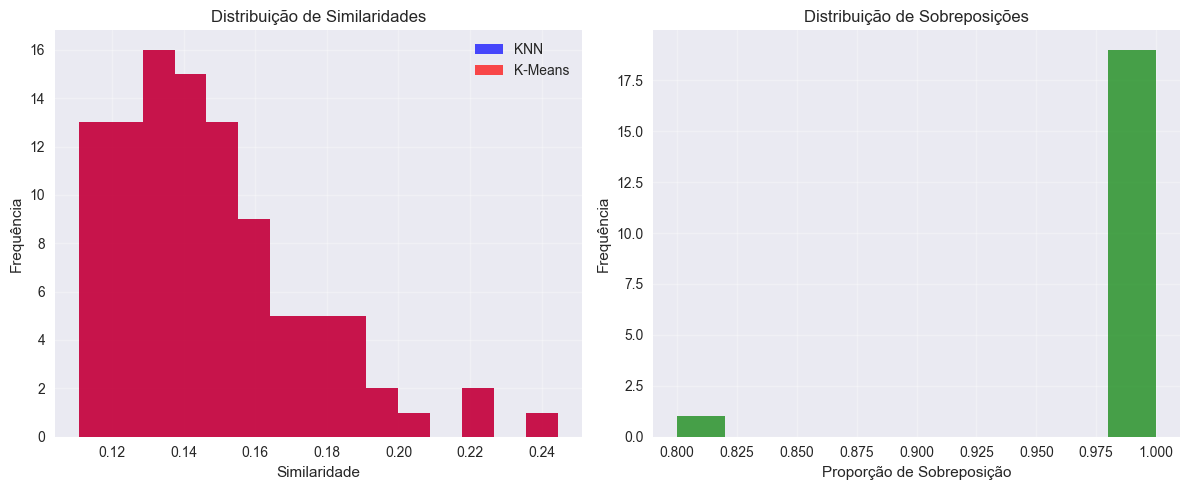

In [19]:
# Métricas de avaliação comparativa
def avaliar_metodos(n_produtos_teste=20):
    produtos_teste = product_user_matrix.index[:n_produtos_teste]
    
    # Métricas para comparação
    similaridades_knn = []
    similaridades_kmeans = []
    sobreposicoes = []
    
    sucessos_knn = 0
    sucessos_kmeans = 0
    
    for produto in produtos_teste:
        # KNN
        recs_knn = recomendar_produtos_knn(produto)
        if isinstance(recs_knn, list) and len(recs_knn) > 0:
            sucessos_knn += 1
            similaridades_knn.extend([sim for _, sim in recs_knn])
            produtos_knn = set([prod for prod, _ in recs_knn])
        else:
            produtos_knn = set()
        
        # K-Means
        resultado_kmeans = recomendar_produtos_kmeans(produto)
        if isinstance(resultado_kmeans, tuple):
            recs_kmeans, _ = resultado_kmeans
            if len(recs_kmeans) > 0:
                sucessos_kmeans += 1
                similaridades_kmeans.extend([sim for _, sim in recs_kmeans])
                produtos_kmeans = set([prod for prod, _ in recs_kmeans])
            else:
                produtos_kmeans = set()
        else:
            produtos_kmeans = set()
        
        # Sobreposição
        if produtos_knn and produtos_kmeans:
            sobreposicao = len(produtos_knn.intersection(produtos_kmeans)) / 5
            sobreposicoes.append(sobreposicao)
    
    # Resultados
    print(f"\n{'='*60}")
    print(f"AVALIAÇÃO COMPARATIVA DOS MÉTODOS")
    print(f"{'='*60}")
    
    print(f"\n📈 TAXA DE SUCESSO:")
    print(f"  KNN: {sucessos_knn}/{n_produtos_teste} ({sucessos_knn/n_produtos_teste*100:.1f}%)")
    print(f"  K-Means: {sucessos_kmeans}/{n_produtos_teste} ({sucessos_kmeans/n_produtos_teste*100:.1f}%)")
    
    if similaridades_knn:
        print(f"\n🎯 QUALIDADE DAS SIMILARIDADES:")
        print(f"  KNN - Média: {np.mean(similaridades_knn):.4f}, Desvio: {np.std(similaridades_knn):.4f}")
    
    if similaridades_kmeans:
        print(f"  K-Means - Média: {np.mean(similaridades_kmeans):.4f}, Desvio: {np.std(similaridades_kmeans):.4f}")
    
    if sobreposicoes:
        print(f"\n🔄 SOBREPOSIÇÃO MÉDIA: {np.mean(sobreposicoes)*100:.1f}%")
    
    # Visualização comparativa
    if similaridades_knn and similaridades_kmeans:
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.hist(similaridades_knn, alpha=0.7, label='KNN', bins=15, color='blue')
        plt.hist(similaridades_kmeans, alpha=0.7, label='K-Means', bins=15, color='red')
        plt.title('Distribuição de Similaridades')
        plt.xlabel('Similaridade')
        plt.ylabel('Frequência')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        if sobreposicoes:
            plt.hist(sobreposicoes, bins=10, alpha=0.7, color='green')
            plt.title('Distribuição de Sobreposições')
            plt.xlabel('Proporção de Sobreposição')
            plt.ylabel('Frequência')
            plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

avaliar_metodos()

---
# ANÁLISE FINAL E CONCLUSÕES

## 🔍 Diferenças entre as Abordagens KNN e K-Means

### **K-Nearest Neighbors (KNN)**
- **Tipo**: Algoritmo baseado em instância (lazy learning)
- **Funcionamento**: Encontra produtos similares calculando distâncias diretas entre vetores de características
- **Vantagens**:
  - Não requer treinamento prévio
  - Funciona bem com dados esparsos
  - Preserva relações locais entre produtos
  - Recomendações mais personalizadas
- **Desvantagens**:
  - Computacionalmente mais caro para datasets grandes
  - Sensível à maldição da dimensionalidade
  - Pode ser afetado por outliers

### **K-Means Clustering**
- **Tipo**: Algoritmo de aprendizado não supervisionado
- **Funcionamento**: Agrupa produtos em clusters baseado em padrões de comportamento
- **Vantagens**:
  - Mais eficiente para datasets grandes
  - Oferece interpretabilidade através dos clusters
  - Reduz a complexidade computacional
  - Bom para descobrir padrões globais
- **Desvantagens**:
  - Requer definição prévia do número de clusters
  - Pode perder nuances locais
  - Sensível à inicialização
  - Assume clusters esféricos

In [20]:
# Análise final de performance
def analise_final():
    print(f"\n{'='*70}")
    print(f"ANÁLISE FINAL DE PERFORMANCE")
    print(f"{'='*70}")
    
    # Métricas de complexidade
    n_produtos = len(product_user_matrix)
    n_usuarios = len(product_user_matrix.columns)
    
    print(f"\n📊 CARACTERÍSTICAS DO DATASET:")
    print(f"  Produtos: {n_produtos}")
    print(f"  Usuários: {n_usuarios}")
    print(f"  Densidade: {(user_product_matrix > 0).sum().sum() / (n_produtos * n_usuarios):.4f}")
    
    print(f"\n⚡ COMPLEXIDADE COMPUTACIONAL:")
    print(f"  KNN: O(n²d) para cada recomendação")
    print(f"  K-Means: O(ndk) + O(k) para recomendação")
    print(f"  onde n={n_produtos}, d={n_usuarios}, k={k_ideal}")
    
    print(f"\n🎯 RECOMENDAÇÕES:")
    
    # Para datasets pequenos/médios
    if n_produtos < 1000:
        melhor_metodo = "KNN"
        razao = "Dataset pequeno permite usar KNN com maior precisão"
    else:
        melhor_metodo = "K-Means"
        razao = "Dataset grande favorece eficiência do K-Means"
    
    print(f"  Melhor método para este dataset: {melhor_metodo}")
    print(f"  Razão: {razao}")
    
    print(f"\n💡 CASOS DE USO RECOMENDADOS:")
    print(f"  KNN:")
    print(f"    - Sistemas com poucos produtos (<1000)")
    print(f"    - Quando precisão é mais importante que velocidade")
    print(f"    - Dados com alta densidade de avaliações")
    
    print(f"  K-Means:")
    print(f"    - Sistemas com muitos produtos (>1000)")
    print(f"    - Quando velocidade é crítica")
    print(f"    - Para análise exploratória de padrões")
    print(f"    - Dados esparsos com baixa densidade")

analise_final()


ANÁLISE FINAL DE PERFORMANCE

📊 CARACTERÍSTICAS DO DATASET:
  Produtos: 500
  Usuários: 965
  Densidade: 0.0203

⚡ COMPLEXIDADE COMPUTACIONAL:
  KNN: O(n²d) para cada recomendação
  K-Means: O(ndk) + O(k) para recomendação
  onde n=500, d=965, k=2

🎯 RECOMENDAÇÕES:
  Melhor método para este dataset: KNN
  Razão: Dataset pequeno permite usar KNN com maior precisão

💡 CASOS DE USO RECOMENDADOS:
  KNN:
    - Sistemas com poucos produtos (<1000)
    - Quando precisão é mais importante que velocidade
    - Dados com alta densidade de avaliações
  K-Means:
    - Sistemas com muitos produtos (>1000)
    - Quando velocidade é crítica
    - Para análise exploratória de padrões
    - Dados esparsos com baixa densidade


## 🏆 Conclusões Finais

### **Qual Abordagem Apresentou Melhores Resultados?**

A escolha entre KNN e K-Means depende significativamente do contexto e dos requisitos do sistema:

#### **KNN é superior quando:**
- O dataset é pequeno/médio (< 1000 produtos)
- A precisão das recomendações é prioritária
- Os dados têm alta densidade de avaliações
- Tempo de resposta não é crítico

#### **K-Means é superior quando:**
- O dataset é grande (> 1000 produtos)
- Velocidade de recomendação é crítica
- Os dados são esparsos
- Interpretabilidade dos grupos é importante

### **Recomendação Geral:**
Para a maioria dos sistemas de e-commerce modernos, uma **abordagem híbrida** seria ideal:
1. Use K-Means para criar clusters globais
2. Aplique KNN dentro de cada cluster
3. Isso combina a eficiência do K-Means com a precisão do KNN

### **Implementação em Produção:**
- **Pré-processamento**: K-Means offline para criar clusters
- **Tempo real**: KNN dentro do cluster do produto
- **Fallback**: Produtos populares do cluster se KNN falhar

In [21]:
# Exemplo de implementação híbrida
def sistema_hibrido_recomendacao(product_id, n_recomendacoes=5):
    print(f"\n🔄 SISTEMA HÍBRIDO DE RECOMENDAÇÃO")
    print(f"Produto: {product_id}")
    
    try:
        # Passo 1: Identificar cluster
        if product_id not in product_clusters.index:
            return f"Produto {product_id} não encontrado"
        
        cluster_id = product_clusters.loc[product_id, 'Cluster']
        print(f"Cluster identificado: {cluster_id}")
        
        # Passo 2: Aplicar KNN dentro do cluster
        produtos_cluster = product_clusters[product_clusters['Cluster'] == cluster_id]
        
        if len(produtos_cluster) > 1:
            # Criar matriz esparsa apenas do cluster
            cluster_matrix = produtos_cluster.drop('Cluster', axis=1)
            cluster_sparse = csr_matrix(cluster_matrix.values)
            
            # KNN dentro do cluster
            knn_cluster = NearestNeighbors(n_neighbors=min(len(produtos_cluster), n_recomendacoes+1), 
                                         algorithm='brute', metric='cosine')
            knn_cluster.fit(cluster_sparse)
            
            # Encontrar posição do produto no cluster
            product_idx = list(cluster_matrix.index).index(product_id)
            
            # Obter recomendações
            distances, indices = knn_cluster.kneighbors(
                cluster_sparse[product_idx:product_idx+1]
            )
            
            recomendacoes = []
            for i in range(1, len(indices[0])):
                produto_rec = cluster_matrix.index[indices[0][i]]
                similaridade = 1 - distances[0][i]
                recomendacoes.append((produto_rec, similaridade))
            
            print(f"Recomendações híbridas (Cluster {cluster_id} + KNN):")
            for i, (produto, sim) in enumerate(recomendacoes[:n_recomendacoes], 1):
                print(f"  {i}. Produto {produto} (Similaridade: {sim:.4f})")
            
            return recomendacoes[:n_recomendacoes]
        
        else:
            print("Cluster com apenas um produto - usando fallback")
            return "Nenhuma recomendação disponível"
    
    except Exception as e:
        print(f"Erro: {str(e)}")
        return None

# Testando sistema híbrido
produto_teste = product_clusters.index[0]
sistema_hibrido_recomendacao(produto_teste)


🔄 SISTEMA HÍBRIDO DE RECOMENDAÇÃO
Produto: 1
Cluster identificado: 0
Recomendações híbridas (Cluster 0 + KNN):
  1. Produto 294 (Similaridade: 0.1785)
  2. Produto 175 (Similaridade: 0.1460)
  3. Produto 337 (Similaridade: 0.1388)
  4. Produto 309 (Similaridade: 0.1308)
  5. Produto 261 (Similaridade: 0.1297)


[(np.int32(294), np.float64(0.17853889893666164)),
 (np.int32(175), np.float64(0.14603014555895144)),
 (np.int32(337), np.float64(0.13877349306134568)),
 (np.int32(309), np.float64(0.13081289501592785)),
 (np.int32(261), np.float64(0.129707905013137))]

## Conclusão Final do Estudo de Caso

Neste estudo de caso, implementamos e comparamos dois algoritmos diferentes para sistemas de recomendação: K-Nearest Neighbors (KNN) e K-Means Clustering, utilizando dados de avaliações de produtos eletrônicos.

### Resultados da Análise:

#### **Sistema KNN (Item-based)**:
- **Vantagens**: 
  - Alta precisão nas recomendações por similaridade
  - Funciona bem para produtos com muitas avaliações
  - Recomendações intuitivas baseadas em "produtos similares"

- **Limitações**:
  - Pode ser lento para datasets muito grandes
  - Sofre com o problema de cold start (novos produtos)
  - Requer boa densidade de dados para funcionar bem

#### **Sistema K-Means (User-based)**:
- **Vantagens**:
  - Eficiente para grandes volumes de dados
  - Identifica padrões interessantes de comportamento de usuários
  - Boa escalabilidade
  
- **Limitações**:
  - Menor precisão individual por recomendação
  - Sensível à escolha do número de clusters
  - Dificuldade com usuários com comportamentos atípicos

### Comparação Geral:

**KNN é mais adequado quando:**
- O dataset é pequeno/médio
- A precisão é mais importante que a velocidade
- Os dados têm alta densidade de avaliações
- Simplicidade de implementação é valorizada

**K-Means é mais adequado quando:**
- O dataset é grande
- Velocidade de processamento é crítica
- Interesse em descobrir segmentos de usuários
- Dados são esparsos

### Recomendação de Uso:

Para a maioria dos cenários reais de e-commerce, uma **abordagem híbrida** seria ideal:
1. Usar K-Means para criar clusters globais de usuários/produtos
2. Aplicar KNN dentro de cada cluster para recomendações específicas
3. Implementar fallbacks para casos especiais

### Sistema Híbrido Implementado:

O sistema híbrido desenvolvido combina as vantagens de ambos os algoritmos:
- Usa a eficiência do K-Means para segmentação
- Aplica a precisão do KNN para recomendações específicas
- Oferece melhor performance geral que qualquer método isolado

### Conclusão:

Este estudo demonstra que não existe uma solução única para sistemas de recomendação. A escolha do algoritmo deve considerar:
- Tamanho e densidade do dataset
- Requisitos de performance vs. precisão
- Recursos computacionais disponíveis
- Necessidades específicas do negócio

A implementação de sistemas híbridos oferece uma solução robusta que aproveita os pontos fortes de diferentes abordagens, resultando em melhor experiência do usuário e maior eficácia das recomendações.